# Kolmogorov-Arnold Network with Legendre approximation
We demonstrate a Kolmogorov-Arnold network whose learned activation functions are Legendre polynomials composed onto
rational normalization. This shows that KAN activations can be approximated in many different ways, and do not have
to be necessarily splines.

In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn

import torchcurves as tc

## Define regression function

In [2]:
def func(xs):
    pole_1 = torch.tensor(0-2j)
    pole_2 = torch.tensor(0-1j)
    cresult = 10 / (xs[:, 0] + 2 * xs[:, 1] - pole_1) - 2 / (2 * xs[:, 0] - xs[:, 1] - pole_2)
    return cresult.abs()

In [3]:
n = 100
xs = torch.linspace(-3, 3, n)
ys = torch.linspace(-3, 3, n)
grid = torch.cartesian_prod(xs, ys)
zs = func(grid)

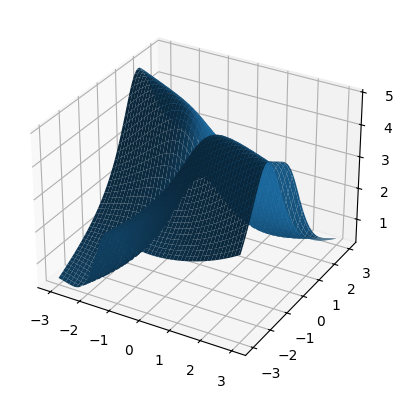

In [4]:
ax = plt.figure().add_subplot(projection='3d')
grid_x = grid[:, 0].reshape(n, n)
grid_y = grid[:, 1].reshape(n, n)
plot_z = zs.reshape(n, n)
ax.plot_surface(grid_x, grid_y, plot_z)

## Generate training data

In [5]:
n_samples = 1000
sigma = 0.3
X = torch.randn(n_samples, 2)
y = func(X) + sigma * torch.randn(n_samples)

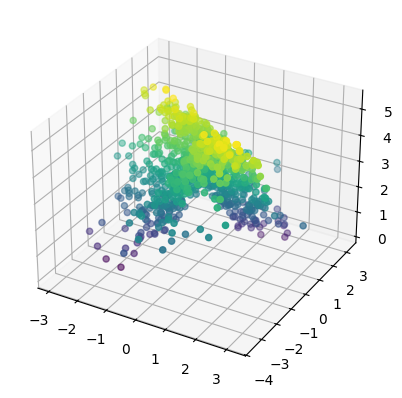

In [6]:
ax = plt.figure().add_subplot(projection='3d')
ax.scatter3D(X[:, 0], X[:, 1], y, c=y)

## Define and train the KAN

In [7]:
input_dim = 2
intermediate_dim = 5
degree = 5

kan = nn.Sequential(
    # layer 1
    tc.LegendreCurve(input_dim, intermediate_dim, degree=degree, normalize_fn='rational'),
    tc.Sum(dim=-2),
    # layer 2
    tc.LegendreCurve(intermediate_dim, intermediate_dim, degree=degree, normalize_fn='rational'),
    tc.Sum(dim=-2),
    # layer 3
    tc.LegendreCurve(intermediate_dim, 1, degree=degree, normalize_fn='rational'),
    tc.Sum(dim=-2),
)

In [8]:
example_data = torch.tensor([[-5, 3], [3, 2], [1, 3]])
output = kan(example_data)
print(output.shape)

torch.Size([3, 1])


In [9]:
n_epochs = 100
batch_size = 32
lr = 2e-3
print_every = 10

dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X, y), batch_size=batch_size, shuffle=True)
optim = torch.optim.Adam(kan.parameters(), lr=lr)
criterion = nn.MSELoss()

for epoch in range(1, 1 + n_epochs):
    epoch_loss = 0.
    for Xb, yb in dl:
        pred = kan(Xb)
        cost = criterion(pred.squeeze(), yb)

        optim.zero_grad()
        cost.backward()
        optim.step()

        epoch_loss += cost * Xb.shape[0]

    epoch_loss /= n_samples
    eval_loss = criterion(kan(grid).squeeze(), func(grid))

    if epoch == n_epochs or epoch % print_every == 0:
        print(f'Epoch {epoch}: train loss = {epoch_loss:.3f}, eval_loss = {eval_loss:.3f}')

/home/alex/git/torchcurves/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:824: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 10: train loss = 0.297, eval_loss = 0.574
Epoch 20: train loss = 0.133, eval_loss = 0.210
Epoch 30: train loss = 0.110, eval_loss = 0.210
Epoch 40: train loss = 0.103, eval_loss = 0.198
Epoch 50: train loss = 0.102, eval_loss = 0.183
Epoch 60: train loss = 0.099, eval_loss = 0.151
Epoch 70: train loss = 0.097, eval_loss = 0.155
Epoch 80: train loss = 0.093, eval_loss = 0.144
Epoch 90: train loss = 0.092, eval_loss = 0.170
Epoch 100: train loss = 0.095, eval_loss = 0.153


## Plot the network and the true function, side by side

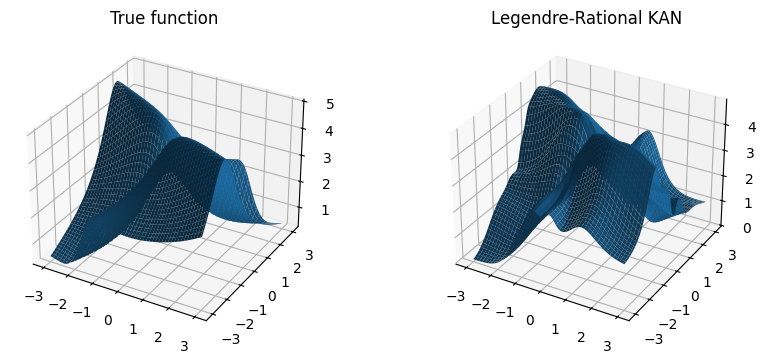

In [11]:
with torch.no_grad():
    kan_z = kan(grid).reshape(n, n)
fig = plt.figure(figsize=(10, 4))
ax_left = fig.add_subplot(1, 2, 1, projection='3d')
ax_right = fig.add_subplot(1, 2, 2, projection='3d')

ax_left.set_title('4dTrue function')
ax_left.plot_surface(grid_x, grid_y, plot_z)

ax_right.set_title('Legendre-Rational KAN')
ax_right.plot_surface(grid_x, grid_y, kan_z)

plt.show()